In [ ]:
!pip install -q kaggle

from google.colab import files

print("⬆️ Upload your kaggle.json (from Kaggle > Account > Create New Token)")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign -p /content

!ls -lh /content

⬆️ Upload your kaggle.json (from Kaggle > Account > Create New Token)


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
 95% 583M/612M [00:01<00:00, 306MB/s]
100% 612M/612M [00:01<00:00, 400MB/s]
total 612M
-rw-r--r-- 1 root root 612M Oct 13  2019  gtsrb-german-traffic-sign.zip
-rw-r--r-- 1 root root   64 Nov 23 17:01 'kaggle (1).json'
-rw-r--r-- 1 root root   64 Nov 23 17:00  kaggle.json
drwxr-xr-x 1 root root 4.0K Nov 20 14:30  sample_data


In [ ]:
!unzip -q /content/gtsrb-german-traffic-sign.zip -d /content/gtsrb

!ls -R /content/gtsrb | head -n 50


/content/gtsrb:
meta
Meta
Meta.csv
test
Test
Test.csv
train
Train
Train.csv

/content/gtsrb/meta:
0.png
10.png
11.png
12.png
13.png
14.png
15.png
16.png
17.png
18.png
19.png
1.png
20.png
21.png
22.png
23.png
24.png
25.png
26.png
27.png
28.png
29.png
2.png
30.png
31.png
32.png
33.png
34.png
35.png
36.png
37.png
38.png
39.png
3.png
40.png
41.png
42.png
4.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
train_dir = "/content/gtsrb/Train"
test_dir  = "/content/gtsrb/Test"


In [ ]:

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

try:
    test_gen = test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    has_test_labels = True
except Exception as e:
    print("⚠️ Could not create labeled test generator:", e)
    print("Proceeding without test set (you can use validation metrics instead).")
    test_gen = None
    has_test_labels = False

num_classes = train_gen.num_classes
print("Number of classes:", num_classes)
print("Class indices:", train_gen.class_indices)


Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Found 0 images belonging to 0 classes.
Number of classes: 43
Class indices: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}


In [ ]:
def build_cnn(input_shape=(48, 48, 3), num_classes=43):
    model = models.Sequential()

    # Block1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Block2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Block3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Classification head
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=num_classes)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,669,771 (10.18 MB)

 Trainable params: 2,669,323 (10.18 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
EPOCHS = 16

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/16
491/491 ━━━━━━━━━━━━━━━━━━━━ 71s 125ms/step - accuracy: 0.3498 - loss: 2.5715 - val_accuracy: 0.4417 - val_loss: 1.9192
Epoch 2/16
491/491 ━━━━━━━━━━━━━━━━━━━━ 54s 110ms/step - accuracy: 0.9198 - loss: 0.2537 - val_accuracy: 0.8649 - val_loss: 0.5388
Epoch 3/16
491/491 ━━━━━━━━━━━━━━━━━━━━ 53s 107ms/step - accuracy: 0.9688 - loss: 0.0958 - val_accuracy: 0.8913 - val_loss: 0.4114
Epoch 4/16
491/491 ━━━━━━━━━━━━━━━━━━━━ 53s 107ms/step - accuracy: 0.9772 - loss: 0.0751 - val_accuracy: 0.8697 - val_loss: 0.6191
Epoch 5/16
491/491 ━━━━━━━━━━━━━━━━━━━━ 53s 107ms/step - accuracy: 0.9808 - loss: 0.0627 - val_accuracy: 0.9146 - val_loss: 0.3504
Epoch 6/16
491/491 ━━━━━━━━━━━━━━━━━━━━ 53s 108ms/step - accuracy: 0.9838 - loss: 0.0549 - val_accuracy: 0.8346 - val_loss: 0.7952
Epoch 7/16
491/491 ━━━━━━━━━━━━━━━━━━━━ 52s 106ms/step - accuracy: 0.9857 - loss: 0.0503 - val_accuracy: 0.8718 - val_loss: 0.6188
Epoch 8/16
491/491 ━━━━━━━━━━━━━━━━━━━━ 53s 108ms/step - accuracy: 0.9835 - loss: 0

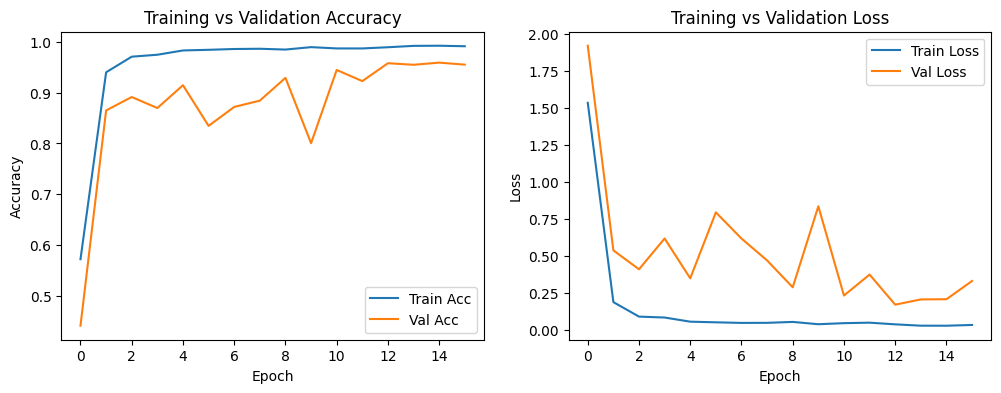

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    plt.show()

plot_history(history)


In [ ]:
if has_test_labels and test_gen is not None and test_gen.n > 0:
    test_loss, test_acc = model.evaluate(test_gen)
    print("✅ Test accuracy:", test_acc)
    print("✅ Test loss:", test_loss)
else:
    print("No labeled test set available or test set is empty, using validation accuracy instead.")


No labeled test set available or test set is empty, using validation accuracy instead.


In [ ]:
# Confusion Matrix
if has_test_labels and test_gen is not None and test_gen.n > 0:
    import itertools
    from sklearn.metrics import confusion_matrix, classification_report

    # Get predictions
    test_gen.reset()
    y_true = test_gen.classes
    y_pred_proba = model.predict(test_gen)
    y_pred = np.argmax(y_pred_proba, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    print("Classification report:")
    class_names = list(test_gen.class_indices.keys())
    print(classification_report(y_true, y_pred, target_names=class_names))

    def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        plt.figure(figsize=(10,10))
        plt.imshow(cm, interpolation='nearest')
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=90)
        plt.yticks(tick_marks, classes)

        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            if cm[i, j] > 0:
                plt.text(j, i, format(cm[i, j], fmt),
                         horizontalalignment="center",
                         fontsize=6,
                         color="white" if cm[i, j] > thresh else "black")

        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()

    plot_confusion_matrix(cm, classes=class_names, normalize=True,
                          title='Normalized Confusion Matrix')
else:
    print("Skipping confusion matrix (no labeled test set or test set is empty).")


Skipping confusion matrix (no labeled test set or test set is empty).


In [ ]:
model.save("gtsrb_traffic_sign_cnn.h5")
print("Model saved as gtsrb_traffic_sign_cnn.h5")


Model saved as gtsrb_traffic_sign_cnn.h5
